# Latent Network Viewer

This notebook loads a trained latent network from `data/latent_network/latent_network.pt`, then plots:

1. prediction vs. target neural activity for one dataset/session/condition
2. latent unit activity and recurrent weights `W`

The final cells expose `W` and the unit slices so you can experiment with recurrent weights interactively.

In [274]:
%matplotlib inline

import copy
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import sklearn

import _8_LatentNetwork as ln
importlib.reload(ln)

checkpoint_path = Path(ln.SAVE_LATENT_PATH) / 'latent_network.pt'
print('checkpoint:', checkpoint_path)
print('exists:', checkpoint_path.exists())

checkpoint: data/latent_network/latent_network.pt
exists: True


## Load The Trained Model

`results` contains the trained RNN, trained session readouts, training metadata, and loss history.

In [276]:
results = ln.load_latent_network(checkpoint_path=str(checkpoint_path))

rnn = results['rnn']
datasets = results['datasets']
loss_history = results['loss_history']

print('loaded datasets:', len(datasets))
print('RNN units:', rnn.n_units)
print('time bins:', rnn.n_time)
print('loss history length:', len(results['loss_history']))

loaded datasets: 10
RNN units: 120
time bins: 24
loss history length: 5000


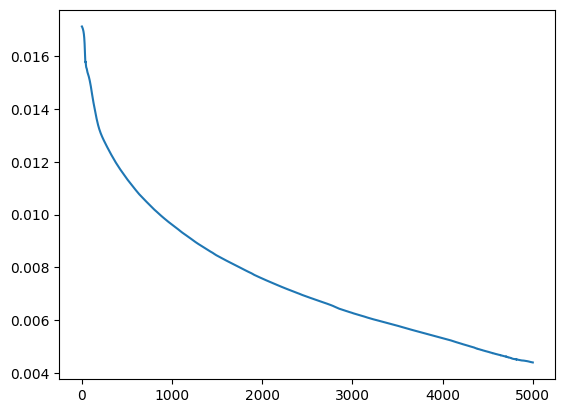

In [277]:
plt.figure()
plt.plot(loss_history)


## Choose An Example

Change these values to inspect a different target dataset, session, or condition.

In [142]:
dataset_idx = 0   # which cells/activity file to use
fx = 0            # session index, 0..32
condition = 'P1'  # one of ln.CONDITIONS, currently ['P1', 'A1']

print('conditions:', ln.CONDITIONS)

conditions: ['P1', 'A1']


## Plot Prediction Vs. Target

This calls the same plotting helper used by `_8_LatentNetwork.py`. Rows are top neurons and columns are time bins.

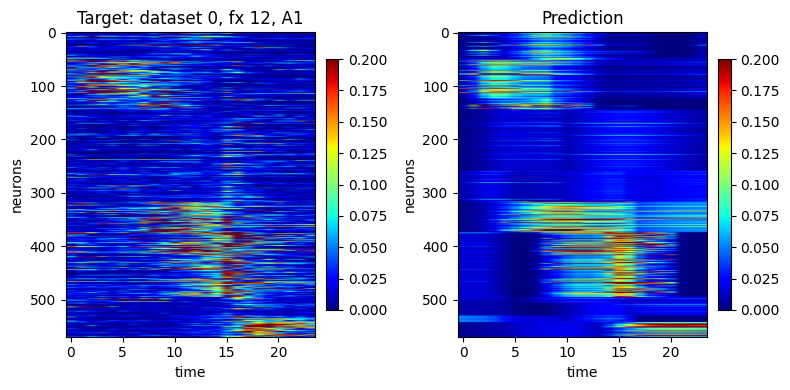

In [278]:
ln.plot_prediction_vs_target(
    results,
    dataset_idx=dataset_idx,
    fx=12,
    condition='A1',
)
plt.show()

## Plot Latent Unit Activity And Recurrent Weights

The units are ordered as `S`, `D`, `R`, and within each population as `Group0`, `Group1`, `Group2`, `Group3`.

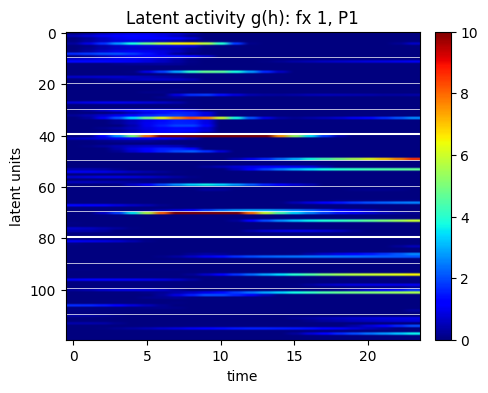

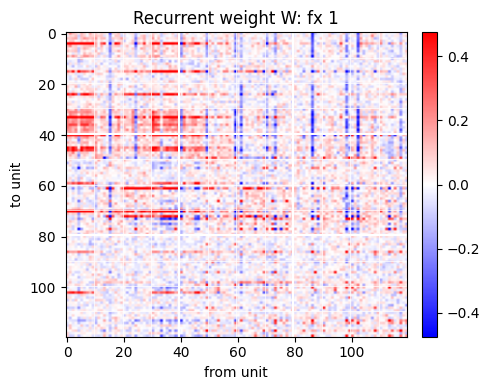

In [273]:
ln.plot_latent_activity_and_weights(
    results,
    condition=condition,
    fx = 1
)
plt.show()

## Inspect The Recurrent Weight Matrix

`W[to_unit, from_unit]` is used in the RNN update through `g(h) @ W.T`. Each session has its own recurrent matrix, so this cell shows `W_by_session[fx]` for the selected session.

KeyboardInterrupt: 

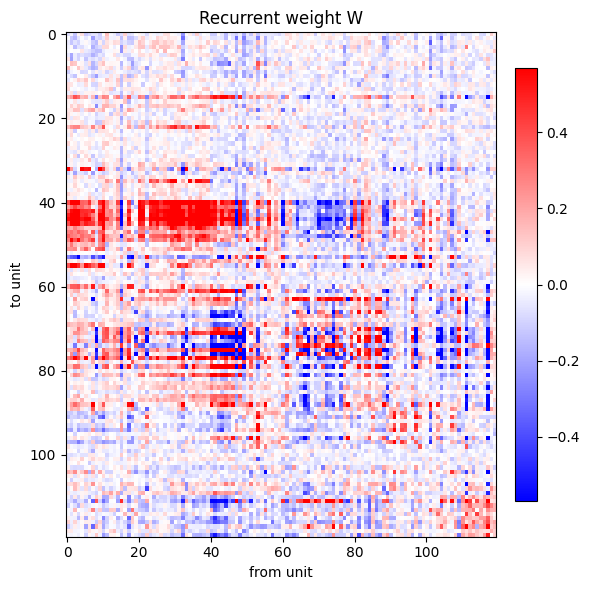

In [282]:
for fx in range(33):
    W = rnn.W_by_session[fx].detach().cpu().numpy()

    plt.figure(figsize=(6,6))
    wlim = np.max(np.abs(W)) / 4
    if wlim == 0:
        wlim = 1
    plt.imshow(W, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
    plt.title('Recurrent weight W')
    plt.xlabel('from unit')
    plt.ylabel('to unit')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f'figure/latent_network/wrec/w{fx}')
    plt.close()

W shape: (120, 120)
W min / mean / max: -2.3506887 -0.008161081 2.5419056

Unit slices:
('S', 'Group0'): 0:10
('S', 'Group1'): 10:20
('S', 'Group2'): 20:30
('S', 'Group3'): 30:40
('D', 'Group0'): 40:50
('D', 'Group1'): 50:60
('D', 'Group2'): 60:70
('D', 'Group3'): 70:80
('R', 'Group0'): 80:90
('R', 'Group1'): 90:100
('R', 'Group2'): 100:110
('R', 'Group3'): 110:120
wstart: 40
wstop: 80


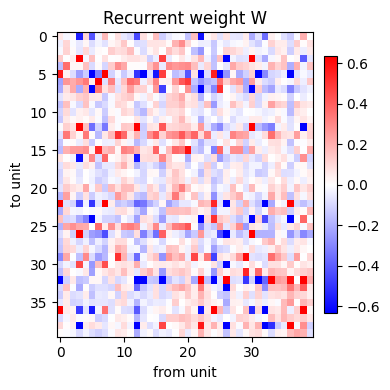

In [ ]:
W = rnn.W_by_session[fx].detach().cpu().numpy()

print('W shape:', W.shape)
print('W min / mean / max:', W.min(), W.mean(), W.max())
print('\nUnit slices:')
for key, sl in ln.UNIT_SLICES.items():
    print(f'{key}: {sl.start}:{sl.stop}')
    if key == ('D','Group0'):
        wstart = sl.start
    if key == ('D','Group3'):
        wstop = sl.stop
print(f'wstart: {wstart}')
print(f'wstop: {wstop}')

Wtrim = W[wstart:wstop,wstart:wstop]
plt.figure(figsize=(4,4))
wlim = np.max(np.abs(W)) / 4
if wlim == 0:
    wlim = 1
plt.imshow(Wtrim, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
plt.title('Recurrent weight W')
plt.xlabel('from unit')
plt.ylabel('to unit')
plt.colorbar(fraction=0.046, pad=0.04)
# plt.xlim([40,80])
# plt.ylim([40,80])
plt.tight_layout()

In [290]:
N=10
fx=10
sv_cumsum = np.zeros((33,12*N))
expvar_cumsum = np.zeros((33,12*N))
components = np.zeros((33,12*N,12*N))
for fx in range(33):
    W = rnn.W_by_session[fx].detach().cpu().numpy()
    # U, S, Vh = np.linalg.svd(W)
    # sv_cumsum[fx] = np.cumsum(S**2) / np.sum(S**2)
    pca = sklearn.decomposition.PCA()
    pca.fit(W.T)
    expvar_cumsum[fx] = np.cumsum(pca.explained_variance_ratio_)
    components[fx] = pca.components_

In [291]:
effdim = np.argmax(expvar_cumsum > 0.8,axis=1)+1
effdim

array([4, 5, 4, 4, 5, 8, 4, 7, 6, 5, 5, 6, 5, 5, 4, 5, 5, 6, 6, 3, 5, 5,
       5, 3, 7, 8, 5, 7, 4, 4, 3, 6, 7])

Text(0, 0.5, 'explained variance')

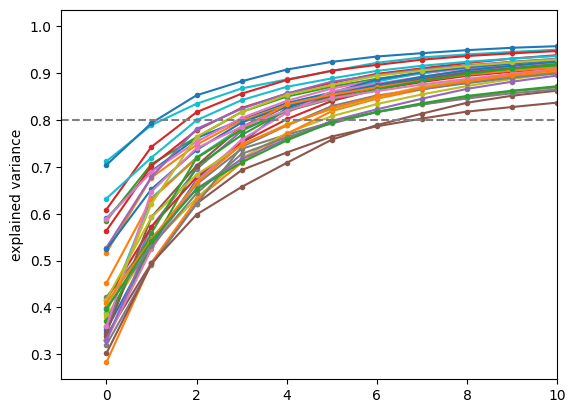

In [295]:
plt.figure()
for fx in range(33):
    # plt.plot(sv_cumsum[fx])
    plt.plot(expvar_cumsum[fx],marker='.')
plt.xlim([-1,10])
plt.axhline(0.8,color='gray',linestyle='--')
# plt.ylim([0.7,0.9])
plt.ylabel('explained variance')

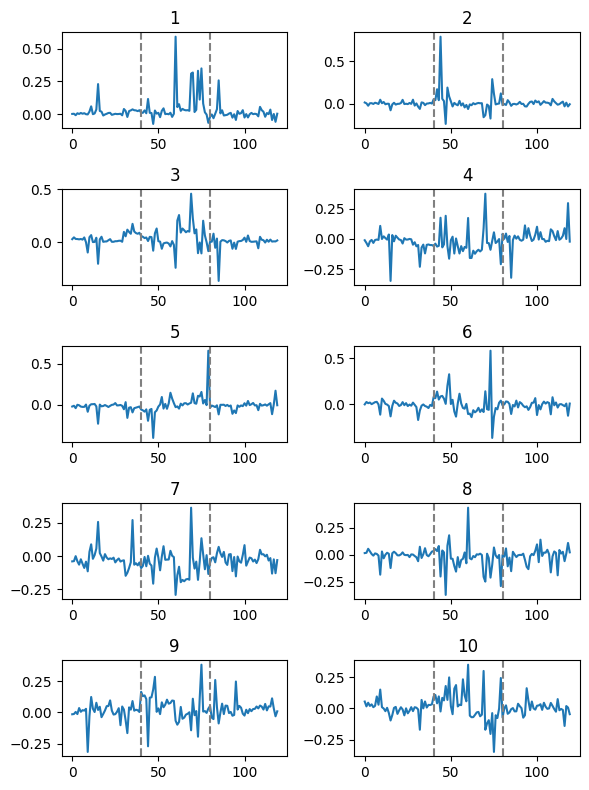

In [294]:
fx1 = 3
fx2 = 23
plt.figure(figsize=(6,8))
for ic in range(10):
    plt.subplot(5,2,ic+1)
    # plt.plot(components[fx1,ic])
    plt.plot(components[fx2,ic])
    plt.axvline(40,color='gray',linestyle='--')
    plt.axvline(80,color='gray',linestyle='--')
    plt.title(f'{ic+1}')
plt.tight_layout()

## Schur decomposition

In [ ]:
from scipy.linalg import schur

T = np.zeros((33,120,120))
Z = np.zeros((33,120,120))
for fx in range(33):
    W = rnn.W_by_session[fx].detach().cpu().numpy()
    T[fx], Z[fx] = schur(W, output='real')

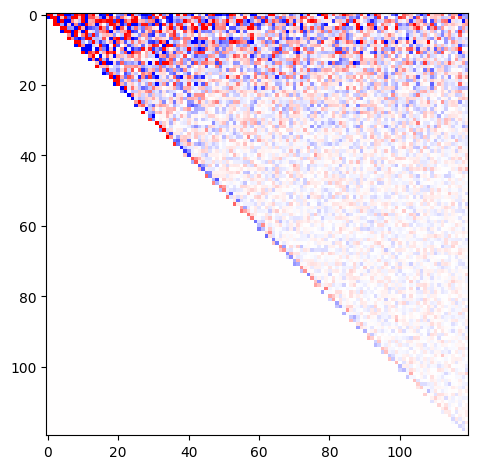

In [211]:
plt.figure()
plt.imshow(T[11],cmap='bwr',vmin=-1,vmax=1)
plt.tight_layout()

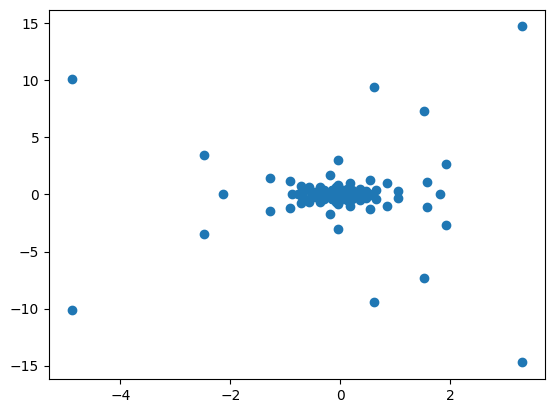

In [242]:
fx=16
W = rnn.W_by_session[fx].detach().cpu().numpy()
eigvals, eigvecs = np.linalg.eig(W)

plt.figure()
plt.scatter(eigvals.real,eigvals.imag)
